# Territory grade and criteria

In [1]:
import geopandas as gpd
import pandas as pd

import os
os.getcwd()

import pickle

## Initialization

Specify the right local CRS for yout territory (make sure it is Projection CRS, not the Geographical CRS).

In [2]:
local_crs = 32637 # Tula region crs 

Initialize the territory

<Axes: >

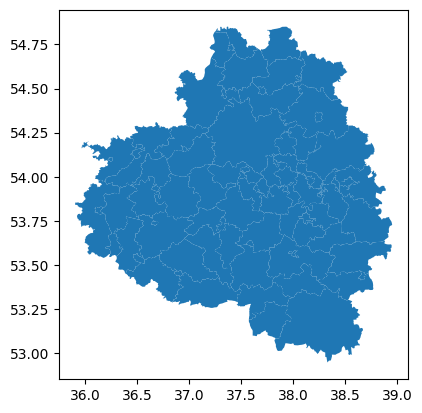

In [3]:
municipalities_polygons = gpd.read_file("data/tula_region_municipalities.geojson")
municipalities_polygons.plot()

## Territory grade (frame-based)

Use the results obtained from ``transport_frames.frame.get_frame()`` and ``transport_frames.frame.weight_roads()``

In [ ]:
with open("data/G_weighted_frame.pickle", "rb") as f:
    weighted_frame = pickle.load(f)

### Territory Grade

Grade is assigned to the territory based on its linear distance to federal and regional roads.

**Road class legend**
- `reg = 1` — **federal**
- `reg = 2` — **regional**

| Condition | Grade |
|---|---:|
| Priority federal node (`reg=1`) within 5 km | 5.0 |
| Federal node (`reg=1`) within 5 km | 4.5 |
| Priority regional node (`reg=2`) within 5 km, nearest federal node by graph distance ≤ 10 km | 4.5 |
| Regional node (`reg=2`) within 5 km, nearest federal node by graph distance ≤ 10 km | 4.0 |
| Priority regional node (`reg=2`) within 5 km, nearest federal node by graph distance ≤ 100 km | 3.5 |
| Regional node (`reg=2`) within 5 km, nearest federal node by graph distance ≤ 100 km | 3.0 |
| Regional node (`reg=2`) within 5 km, nearest federal node by graph distance > 100 km | 2.0 |
| No nodes, but graph edges are within 5 km | 1.0 |
| No known roads within 1 km | 0.0 |

**Bonus**
- Railway station within 10 km: `+0.5` (added to the base grade).


In [5]:
from transport_frames.criteria import grade_territory

graded_territory= grade_territory(weighted_frame, municipalities_polygons)
graded_territory

,name,geometry,grade
0,Манаенское,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",3.5
1,Астаповское,"POLYGON ((36.47061 53.63576, 36.48947 53.63114...",3.0
2,Арсеньево,"POLYGON ((36.63005 53.72754, 36.63174 53.72702...",3.0
3,Левобережное,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",3.5
4,Правобережное,"POLYGON ((36.1455 53.80533, 36.14561 53.80468,...",3.5
...,...,...,...
79,Яснополянское,"POLYGON ((37.17494 54.04491, 37.1757 54.0431, ...",5.0
80,Ясногорск,"POLYGON ((37.66036 54.50418, 37.67147 54.4978,...",4.5
81,Теляковское,"POLYGON ((37.60388 54.56328, 37.60784 54.55777...",5.0
82,Ревякинское,"POLYGON ((37.47214 54.48182, 37.47222 54.48006...",5.0


## Transport Criteria

District polygons and settlement points are used for calculating quartile of settlement connectivity of the territory (aggregated by polygons).

In [6]:
districts_polygons = gpd.read_file("data/tula_region_districts.geojson")
settlement_points = gpd.read_file("data/tula_region_towns.geojson")

Initialize the gdfs of railway stations, bus stops, fuel stations and aerodromes. The services should be presented as Points.

In [7]:
railway_stations = gpd.read_file("data/tula_region_railway_stations.geojson")
bus_stops = gpd.read_file("data/tula_region_bus_stops.geojson")
local_aerodrome = gpd.read_file("data/tula_region_aerodrome.geojson")

In [8]:
local_aerodrome["geometry"] = local_aerodrome.geometry.representative_point()

Criteria is calculated based on drive and public tranport connectivity, frame-based grade, distance to the services.


The `Transport` criterion combines:
- the territory position relative to the transport framework;
- the average travel connectivity from the territory to other territories.

**Service Availability Weight (within 15 km)**

| Service | Weight |
|---|---:|
| Bus stop | 0.35 |
| Railway stop/station | 0.35 |
| Port / pier / ferry crossing | 0.20 |
| Airfield | 0.10 |

Rules:
- If several service types are present, weights are summed.
- If a service type is absent, its weight is `0`.
- If all service types are absent, total weight is `W = 0`.

**Apply Quartile-Based Coefficients**

First, determine the average transport connectivity quartile for all municipalities in the project area:
- Q4: worst 25%
- Q3: 75% to 50%
- Q2: 50% to 25%
- Q1: best 25%

Then use transport-framework score `F` and weight `W`:

| `F` | Q4 Private | Q4 Public | Q3 Private | Q3 Public | Q2 Private | Q2 Public | Q1 Private | Q1 Public |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 5.0 | 2 | `2*W` | 3 | `3*W` | 4 | `4*W` | 5 | `5*W` |
| 4.5 | 2 | `2*W` | 3 | `3*W` | 4 | `4*W` | 5 | `5*W` |
| 4.0 | 1 | `2*W` | 2 | `3*W` | 3 | `4*W` | 4 | `5*W` |
| 3.5 | 1 | `1*W` | 2 | `2*W` | 3 | `3*W` | 4 | `5*W` |
| 3.0 | 0 | `1*W` | 1 | `2*W` | 3 | `3*W` | 3 | `4*W` |
| 2.5 | 0 | `1*W` | 1 | `2*W` | 2 | `3*W` | 3 | `4*W` |
| 2.0 | 0 | `0*W` | 1 | `1*W` | 2 | `2*W` | 2 | `4*W` |
| 1.5 | 0 | `0*W` | 0 | `1*W` | 1 | `2*W` | 2 | `3*W` |
| 1.0 | 0 | `0*W` | 0 | `0*W` | 1 | `1*W` | 1 | `3*W` |
| 0.0 | 0 | `0*W` | 0 | `0*W` | 0 | `1*W` | 1 | `2*W` |

**Final Score**

Each territory receives two separate scores: one for private transport and one for public transport.  
The final transport score is obtained by averaging these two scores with equal weight.  
The final value ranges from `0` to `5`.



Connectivity data can be obtained using pre-calculated adjacency matrices or calculated automatically based on graphs.


Adjacency matrices for drive and PT graphs can be calculated using ``iduedu.get_adj_matrix_gdf_to_gdf()``


Drive and intermodal graphs can be obtained using  ``transport_frames.graph.get_graph()`` and ``transport_frames.graph.get_intermodal_graph()``


In [9]:
with open("data/G_drive.pickle", "rb") as f:
    G_drive = pickle.load(f)

with open("data/G_inter.pickle", "rb") as f:
    G_pt = pickle.load(f)

In [10]:
from transport_frames.criteria import get_criteria

criteria_gdf = get_criteria(graded_terr = graded_territory,
                                           towns = settlement_points,
                                           polygons = districts_polygons,
                                           drive_graph = G_drive,
                                           PT_graph = G_pt,
                                           r_stops = railway_stations,
                                           b_stops = bus_stops,
                                           ferry = None, # there aro no ferry ports in Tula region
                                           aero = local_aerodrome,
                                           adj_mx_drive = None,
                                           adj_mx_PT = None,
                                           local_crs = local_crs
                                           )
criteria_gdf

Getting drive matrix


2026-04-05 00:05:02.449 | WARNING  | Removing 197 nodes from 22 smaller strongly connected components. These are subgraphs where nodes are internally reachable but isolated from the rest. Retaining only the largest strongly connected component (31927 nodes).


Getting PT matrix


,geometry,name,grade,weight,weight_r_stops,weight_b_stops,weight_ferry,weight_aero,car_access_quartile,public_access_quartile,car_grade,public_transport_grade,overall_assessment
0,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",Арсеньевский район,3.5,0.35,0.00,0.35,0.0,0.0,4,4,1.0,0.35,0.675
1,"POLYGON ((36.47061 53.63576, 36.48947 53.63114...",Арсеньевский район,3.0,0.70,0.35,0.35,0.0,0.0,4,4,0.0,0.70,0.350
2,"POLYGON ((36.63005 53.72754, 36.63174 53.72702...",Арсеньевский район,3.0,0.35,0.00,0.35,0.0,0.0,4,4,0.0,0.35,0.175
3,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",Белевский район,3.5,0.70,0.35,0.35,0.0,0.0,4,4,1.0,0.70,0.850
4,"POLYGON ((36.1455 53.80533, 36.14561 53.80468,...",Белевский район,3.5,0.70,0.35,0.35,0.0,0.0,4,4,1.0,0.70,0.850
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,"POLYGON ((37.17494 54.04491, 37.1757 54.0431, ...",Щекинский район,5.0,0.70,0.35,0.35,0.0,0.0,1,1,5.0,3.50,4.250
80,"POLYGON ((37.66036 54.50418, 37.67147 54.4978,...",Ясногорский район,4.5,0.80,0.35,0.35,0.0,0.1,2,3,4.0,2.40,3.200
81,"POLYGON ((37.60388 54.56328, 37.60784 54.55777...",Ясногорский район,5.0,0.80,0.35,0.35,0.0,0.1,2,3,4.0,2.40,3.200
82,"POLYGON ((37.47214 54.48182, 37.47222 54.48006...",Ясногорский район,5.0,0.80,0.35,0.35,0.0,0.1,2,3,4.0,2.40,3.200


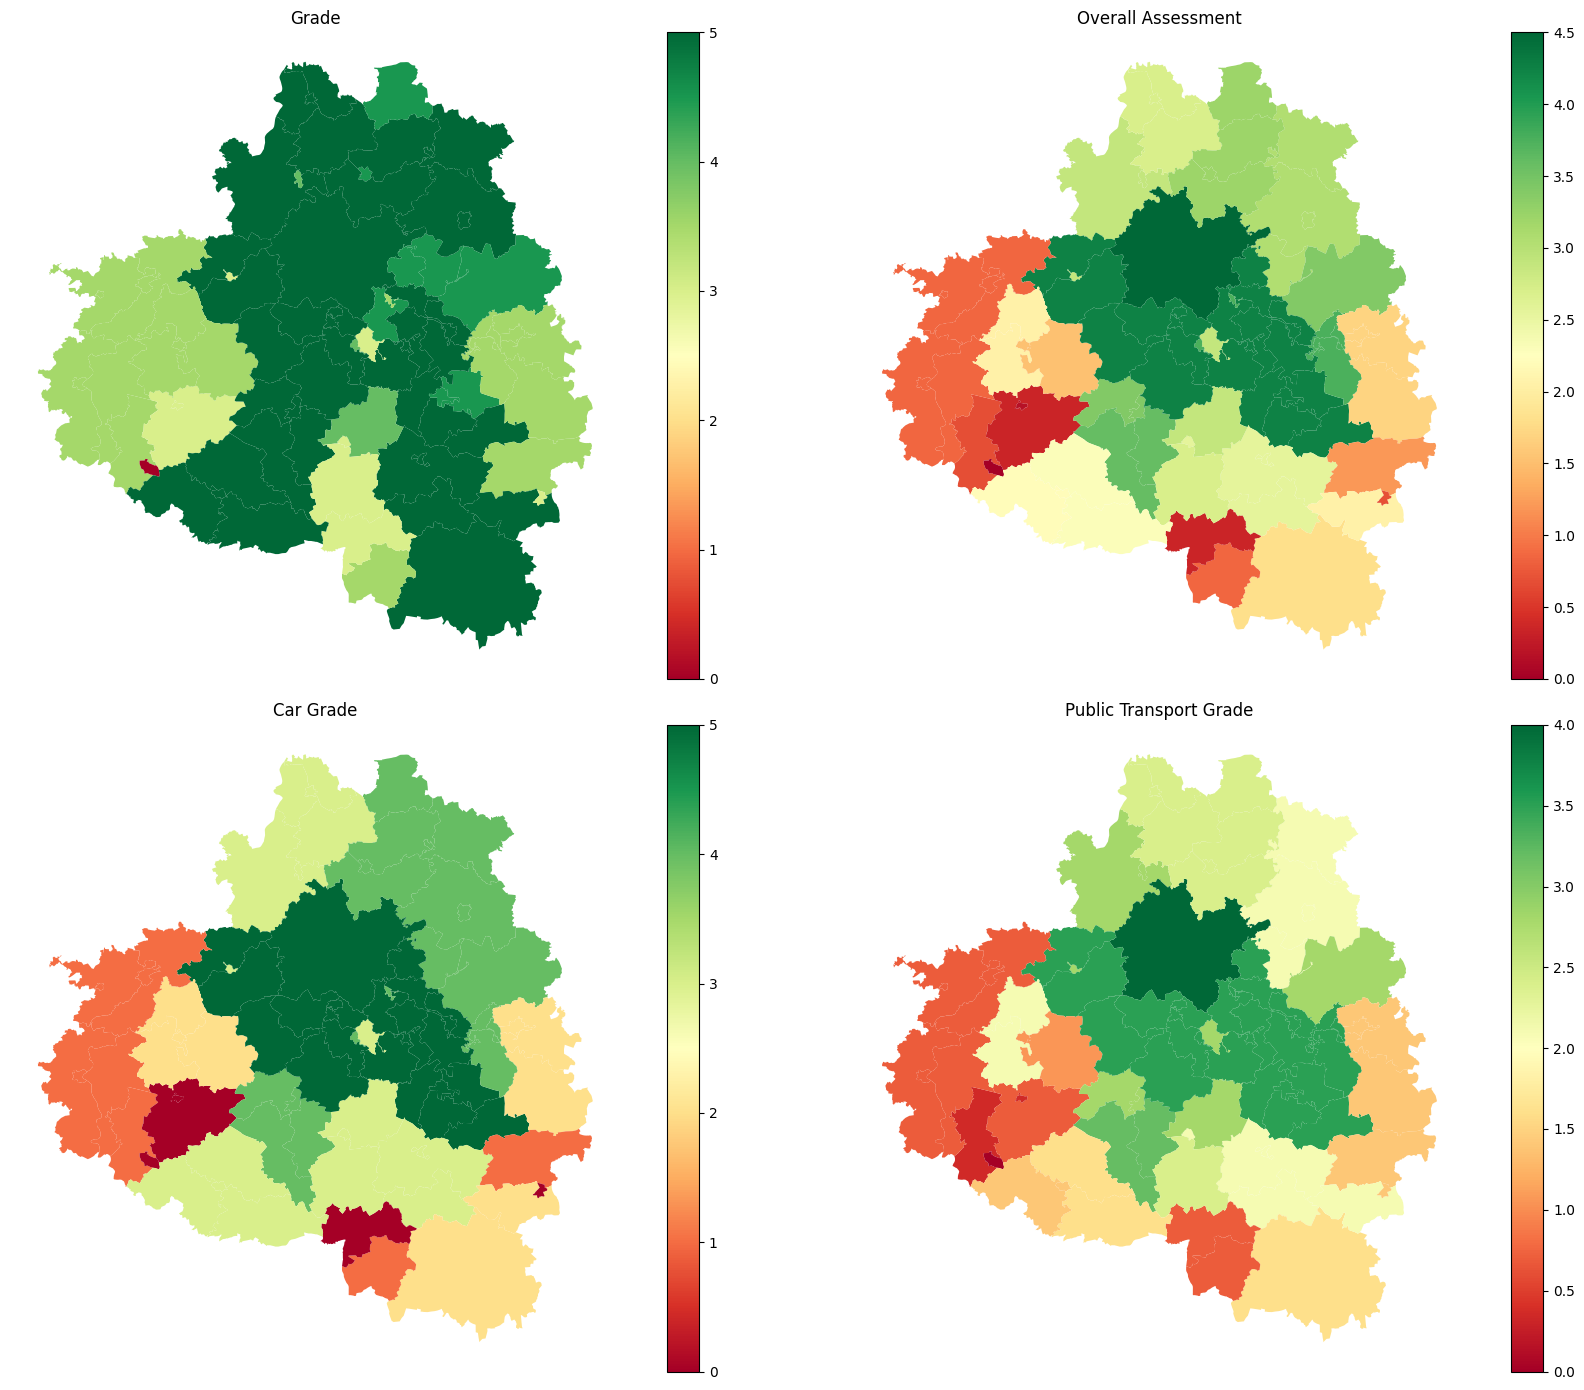

In [11]:
import matplotlib.pyplot as plt

cols = ["grade", "overall_assessment", "car_grade", "public_transport_grade"]
titles = ["Grade", "Overall Assessment", "Car Grade", "Public Transport Grade"]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.ravel()

for ax, col, title in zip(axes, cols, titles):
    plot_kwargs = dict(
        column=col,
        cmap="RdYlGn",
        legend=True,
        linewidth=0.2,
        ax=ax,
    )

    if col == "grade":
        plot_kwargs.update(vmin=0, vmax=5)

    criteria_gdf.plot(**plot_kwargs)
    ax.set_axis_off()
    ax.set_title(title)

plt.tight_layout()
